<a href="https://colab.research.google.com/github/SweetlinN/Manufacturing_quality_rating_prediction/blob/main/Manufacturing_quality_prediction2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# problem statement - quality rating prediction

In [3]:
#The manufacturing dataset consists of the following columns:

#1.	Temperature (°C): This column represents the temperature during the manufacturing process,
#measured in degrees Celsius. Temperature plays a critical role in many manufacturing processes,
#influencing material properties and product quality.

#2.	Pressure (kPa): The pressure applied during the manufacturing process, measured in kilopascals (kPa).
#Pressure can affect the material transformation and the overall outcome of the manufacturing process.

#3.	Temperature x Pressure: This feature is an interaction term between temperature and pressure,
#which captures the combined effect of these two process parameters.

#4.	Material Fusion Metric: A derived metric calculated as the sum of the square of temperature and the cube of pressure.
#It represents a material fusion-related measurement during the manufacturing process.

#5.	Material Transformation Metric: Another derived metric calculated as the cube of temperature minus the square of pressure.
#It provides insight into material transformation dynamics.

#6.	Quality Rating: The target variable, 'Quality Rating,' represents the overall quality rating of the produced items.
#Quality is a crucial aspect of manufacturing, and this rating serves as a measure of the final product's quality.


# 2.Data Gathering

In [4]:
# load data

In [5]:
from google.colab import files
uploaded = files.upload()

Saving manufacturing.csv to manufacturing.csv


In [6]:
df = pd.read_csv('manufacturing.csv')

In [7]:
# first five rows of the dataset

In [8]:
df.head(5)

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [9]:
# last five rows of the dataset

In [10]:
df.tail()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975
3956,163.359996,24.332133,3974.897121,41092.392901,4.358913e+06,100.000000


# 3.(EDA) Read and Explore the data

In [11]:
df.shape

(3957, 6)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [13]:
df.describe()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
count,3957.000000,3957.000000,3957.000000,3957.000000,3.957000e+03,3957.000000
mean,200.034704,14.815558,2955.321308,48127.183128,1.003645e+07,96.260179
std,58.135717,5.772040,1458.224940,23812.213513,7.599356e+06,12.992262
min,100.014490,5.003008,513.706875,10156.971955,9.999462e+05,1.000000
25%,150.871296,9.692984,1798.247303,27626.929091,3.433810e+06,99.941129
50%,198.603371,14.832557,2678.277782,44611.452164,7.833390e+06,99.999997
75%,251.366552,19.749680,3929.058261,67805.443846,1.588251e+07,100.000000
max,299.992804,24.999132,7365.018714,103756.181544,2.699783e+07,100.000000


In [14]:
df.isna().sum()

,0
Temperature (°C),0
Pressure (kPa),0
Temperature x Pressure,0
Material Fusion Metric,0
Material Transformation Metric,0
Quality Rating,0


# 4. data visualization

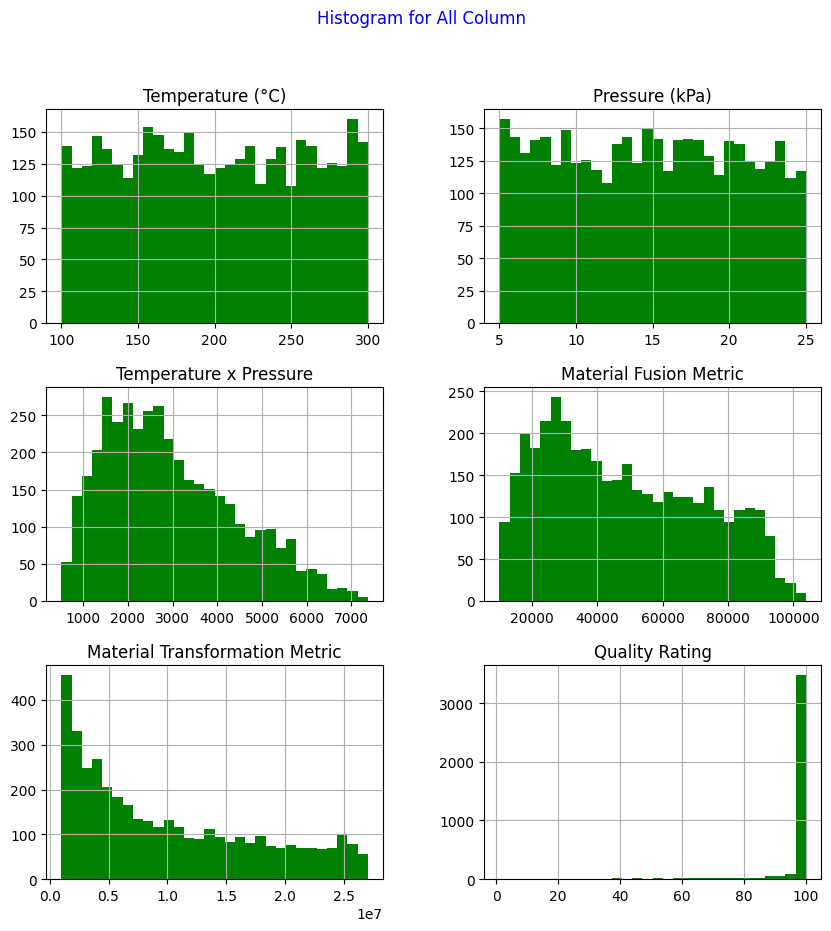

In [20]:
df.hist(figsize=(10,10),color='green',bins=30)
plt.suptitle("Histogram for All Column",color='blue')
plt.show()


<Axes: >

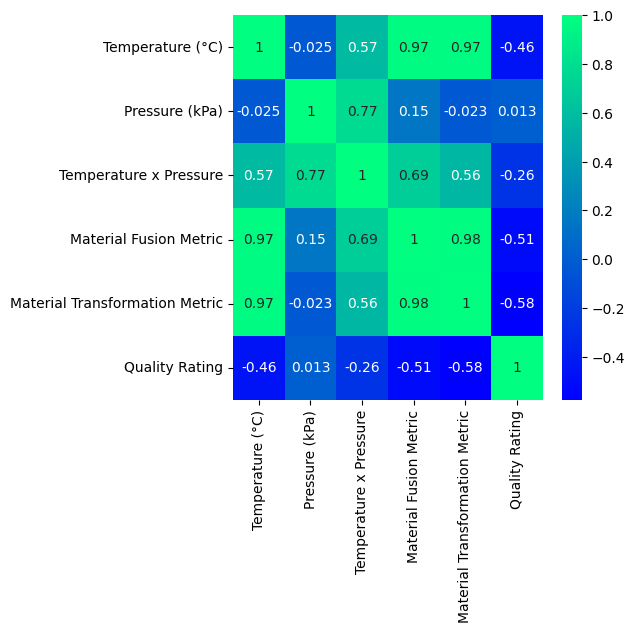

In [28]:
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(),annot=True,linecolor='g',cmap='winter')

# 5. Train_test_split